In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import pandas as pd
import batman

In [15]:
df = pd.read_csv('all_results_toP14.csv')
fraction_true = (df['Detection'] == 'True').sum() / len(df)
print(f"Detection True/Total Fraction: {fraction_true:.3f}")
toi_df = pd.read_csv('TOI_Mar2025_1pt5to4_R_with_Mst.csv')

df['TOI'] = df['TOI'].astype(str)
toi_df['toi'] = toi_df['toi'].astype(str)

df_full = df.merge(toi_df, left_on='TOI', right_on='toi', how='inner')
print(df_full['pl_orbper'].head)
print(df_full['True Period (Days)'].head)
print(df_full.head())

Detection True/Total Fraction: 0.144
<bound method NDFrame.head of 0       3.577501
1       7.188733
2       1.917096
3       0.305261
4      12.302750
         ...    
729    13.823303
730    11.020153
731     2.573594
732     3.529850
733     4.327650
Name: pl_orbper, Length: 734, dtype: float64>
<bound method NDFrame.head of 0       3.6
1       7.2
2       1.9
3       0.3
4      12.3
       ... 
729    13.8
730    11.0
731     2.6
732     3.5
733     4.3
Name: True Period (Days), Length: 734, dtype: float64>
       TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
0  5165.01  TIC 349986198     3143.98            0.74               4642.1   
1   512.01  TIC 119292328      159.69            0.92               5581.0   
2  7170.01   TIC 63100069     1922.88            0.52               3653.0   
3  6940.01  TIC 421006834     1419.95            0.36               3338.0   
4  6944.01  TIC 421005422      343.29            0.88               5181.1   

   Stellar Mag

In [4]:
#derived from histogram_rad_cliff.ipynb
# Using 3 n_transits and SNR = 2

# #rp_min = rs_earth * np.sqrt(snr_target * uncert / np.sqrt(n_trans))

temp_bins = [
    "3000-3500K", "3500-4000K", "4000-4500K", "4500-5000K",
    "5000-5500K", "5500-6000K", "6000-6500K", "6500-7000K"
]
min_radii = [1.40, 1.54, 1.79, 1.73, 1.87, 1.94, 2.31, 2.57]

min_detectable_df = pd.DataFrame({
    "Temperature Bin": temp_bins,
    "Minimum Detectable Planet Radius (Rearth)": min_radii
})

print(min_detectable_df)


  Temperature Bin  Minimum Detectable Planet Radius (Rearth)
0      3000-3500K                                       1.40
1      3500-4000K                                       1.54
2      4000-4500K                                       1.79
3      4500-5000K                                       1.73
4      5000-5500K                                       1.87
5      5500-6000K                                       1.94
6      6000-6500K                                       2.31
7      6500-7000K                                       2.57


In [5]:
#merge minimum planets to each row
def get_temp_bin(temp):
    for i, bin_label in enumerate(temp_bins):
        low, high = map(int, bin_label.replace('K', '').split('-'))
        if low <= temp < high:
            return bin_label
    return None

df['Temperature Bin'] = df['Stellar Temperature'].apply(get_temp_bin)
df_merged = df.merge(min_detectable_df, on='Temperature Bin', how='left')
print(df_merged)

         TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
0    5165.01  TIC 349986198     3143.98            0.74               4642.1   
1     512.01  TIC 119292328      159.69            0.92               5581.0   
2    7170.01   TIC 63100069     1922.88            0.52               3653.0   
3    6940.01  TIC 421006834     1419.95            0.36               3338.0   
4    6944.01  TIC 421005422      343.29            0.88               5181.1   
..       ...            ...         ...             ...                  ...   
729   821.01  TIC 125405602      443.35            0.44               3669.0   
730   875.01   TIC 14165625      642.05            0.67               4407.0   
731   880.02   TIC 34077285      279.22            0.81               4935.0   
732   896.01  TIC 102283403      185.68            1.39               6627.0   
733   942.01  TIC 146520535      435.79            0.81               4945.0   

     Stellar Magnitude  True Radius (Ea

In [6]:
df_above_min = df_merged[df_merged['True Radius (Earth Radii)'] > df_merged['Minimum Detectable Planet Radius (Rearth)']]
print(f'{len(df_above_min)}/{len(df_merged)} planets above minimum detectable radius')

n_true = (df_above_min['Detection'] == 'True').sum()
n_false = (df_above_min['Detection'] == 'False').sum()
print(f"Above minimum detectable radius: Detection=True: {n_true}, Detection=False: {n_false}")

df_below_min = df_merged[df_merged['True Radius (Earth Radii)'] <= df_merged['Minimum Detectable Planet Radius (Rearth)']]
print(f'{len(df_below_min)}/{len(df_merged)} planets below minimum detectable radius')
n_true_below = (df_below_min['Detection'] == 'True').sum()
n_false_below = (df_below_min['Detection'] == 'False').sum()
print(f"Below minimum detectable radius: Detection=True: {n_true_below}, Detection=False: {n_false_below}")

632/734 planets above minimum detectable radius
Above minimum detectable radius: Detection=True: 108, Detection=False: 524
102/734 planets below minimum detectable radius
Below minimum detectable radius: Detection=True: 10, Detection=False: 92


Plotting lightcurve for TIC 349986198, TOI 5165.01
       TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
0  5165.01  TIC 349986198     3143.98            0.74               4642.1   

   Stellar Magnitude  True Radius (Earth Radii)  True Period (Days) Detection  \
0            12.5389                        3.3                 3.6     False   

   TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs   TLS FAP  \
0      3.5726                 0.01179   0.998007   0.040144  0.062825   

    TLS SNR      toi         id tfopwg_disp         rastr          ra  \
0  5.104603  5165.01  349986198          PC  10h17m00.04s  154.250153   

          decstr       dec  st_pmra  st_pmraerr1  st_pmraerr2  st_pmralim  \
0  +06d51m59.32s  6.866478  -63.855        0.047       -0.047         0.0   

   st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim    pl_tranmid  \
0     4.976          0.05         -0.05          0.0  2.459547e+06   

   pl_tranmiderr1  pl_tranmiderr2  pl_t

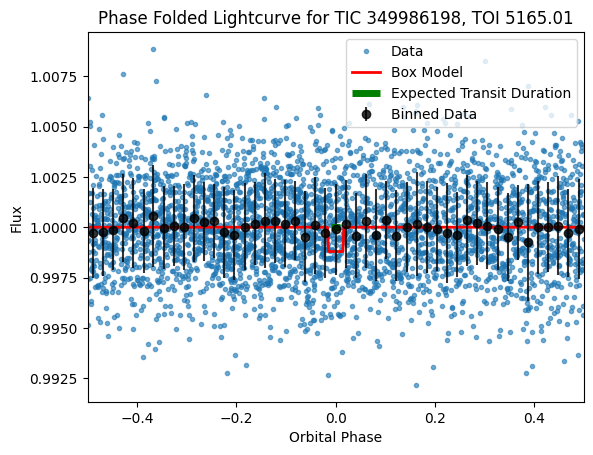

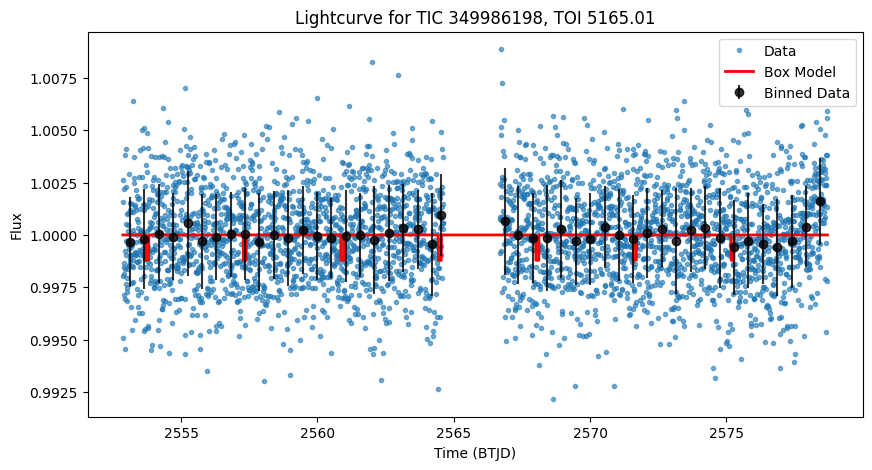

Plotting lightcurve for TIC 119292328, TOI 512.01
Empty DataFrame
Columns: [TOI, TIC, CDPP (ppm), Stellar Radius, Stellar Temperature, Stellar Magnitude, True Radius (Earth Radii), True Period (Days), Detection, TLS Period, TLS Period Uncertainty, TLS Depth, TLS Rp/Rs, TLS FAP, TLS SNR, toi, id, tfopwg_disp, rastr, ra, decstr, dec, st_pmra, st_pmraerr1, st_pmraerr2, st_pmralim, st_pmdec, st_pmdecerr1, st_pmdecerr2, st_pmdeclim, pl_tranmid, pl_tranmiderr1, pl_tranmiderr2, pl_tranmidlim, pl_orbper, pl_orbpererr1, pl_orbpererr2, pl_orbperlim, pl_trandurh, pl_trandurherr1, pl_trandurherr2, pl_trandurhlim, pl_trandep, pl_trandeperr1, pl_trandeperr2, pl_trandeplim, pl_rade, pl_radeerr1, pl_radeerr2, pl_radelim, pl_insol, pl_insolerr1, pl_insolerr2, pl_insollim, pl_eqt, pl_eqterr1, pl_eqterr2, pl_eqtlim, st_tmag, st_tmagerr1, st_tmagerr2, st_tmaglim, st_dist, st_disterr1, st_disterr2, st_distlim, st_teff, st_tefferr1, st_tefferr2, st_tefflim, st_logg, st_loggerr1, st_loggerr2, st_logglim, st_

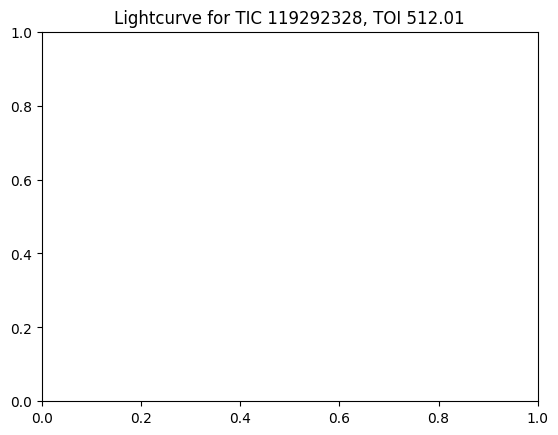

Plotting lightcurve for TIC 421006834, TOI 6940.01
       TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
3  6940.01  TIC 421006834     1419.95            0.36               3338.0   

   Stellar Magnitude  True Radius (Earth Radii)  True Period (Days) Detection  \
3            12.5437                       2.03                 0.3     False   

   TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs  TLS FAP  \
3   11.454893                0.083985   0.994279   0.068023  0.00008   

    TLS SNR      toi         id tfopwg_disp         rastr          ra  \
3  12.20107  6940.01  421006834          PC  07h27m28.97s  111.870696   

          decstr        dec  st_pmra  st_pmraerr1  st_pmraerr2  st_pmralim  \
3  +11d27m58.61s  11.466281  -81.454        0.127       -0.127         0.0   

   st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim    pl_tranmid  \
3   -28.691         0.101        -0.101          0.0  2.460286e+06   

   pl_tranmiderr1  pl_tranmiderr2  pl_t

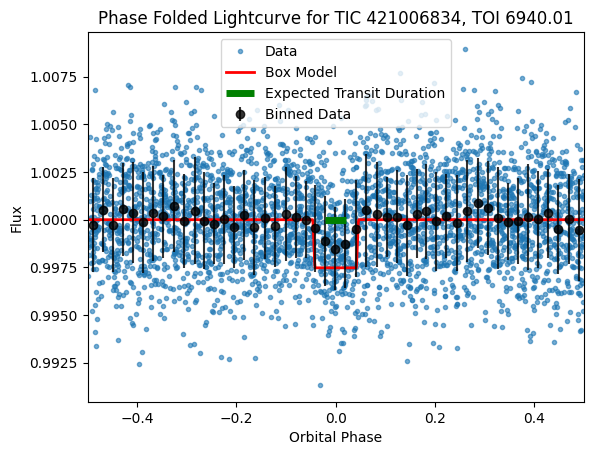

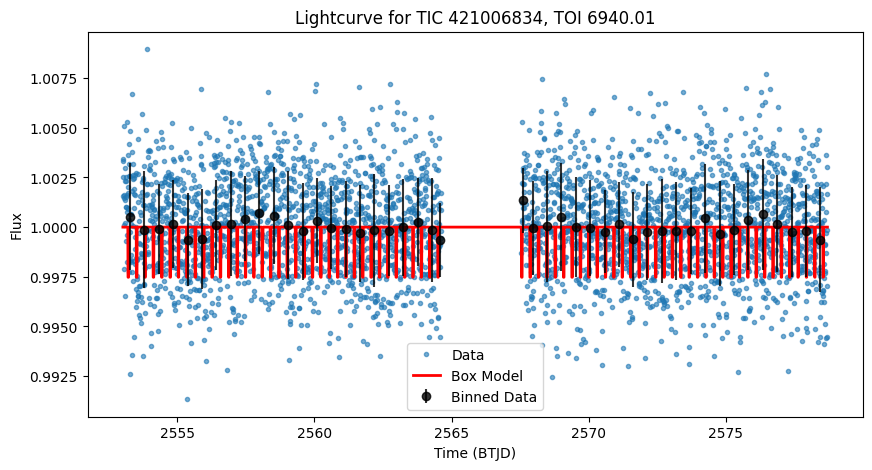

Plotting lightcurve for TIC 421005422, TOI 6944.01
       TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
4  6944.01  TIC 421005422      343.29            0.88               5181.1   

   Stellar Magnitude  True Radius (Earth Radii)  True Period (Days) Detection  \
4            10.7077                       2.61                12.3     False   

   TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs  TLS FAP  \
4    4.733652                0.064357   0.999316   0.023519      NaN   

     TLS SNR      toi         id tfopwg_disp         rastr          ra  \
4  11.367515  6944.01  421005422          PC  07h27m42.73s  111.928044   

          decstr      dec  st_pmra  st_pmraerr1  st_pmraerr2  st_pmralim  \
4  +09d58m10.38s  9.96955  -37.003        0.061       -0.061         0.0   

   st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim    pl_tranmid  \
4    -5.961         0.047        -0.047          0.0  2.460272e+06   

   pl_tranmiderr1  pl_tranmiderr2  pl_tra

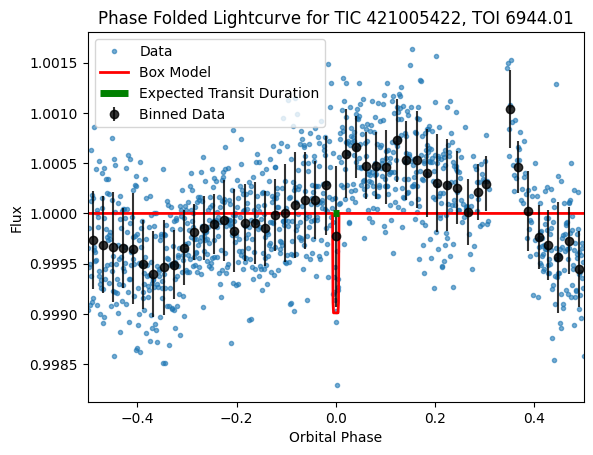

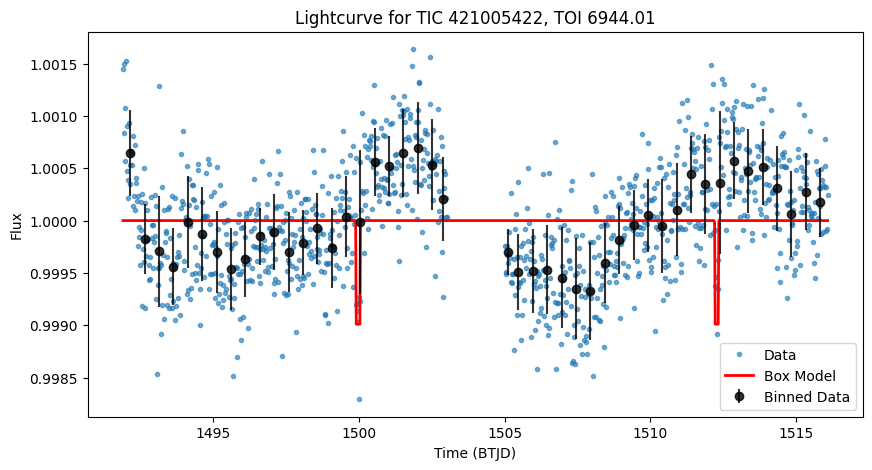

Plotting lightcurve for TIC 437011608, TOI 5082.01
       TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
8  5082.01  TIC 437011608       90.88            1.01               5670.0   

   Stellar Magnitude  True Radius (Earth Radii)  True Period (Days) Detection  \
8             7.6253                       2.64                 4.2     False   

   TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs   TLS FAP  \
8    5.938288                0.136415   0.994042   0.069418  0.004882   

     TLS SNR      toi         id tfopwg_disp        rastr          ra  \
8  34.883096  5082.01  437011608          PC  07h06m16.7s  106.569578   

          decstr        dec  st_pmra  st_pmraerr1  st_pmraerr2  st_pmralim  \
8  +22d40m59.33s  22.683148  -92.348         0.08        -0.08         0.0   

   st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim    pl_tranmid  \
8   -78.817          0.07         -0.07          0.0  2.460285e+06   

   pl_tranmiderr1  pl_tranmiderr2  pl

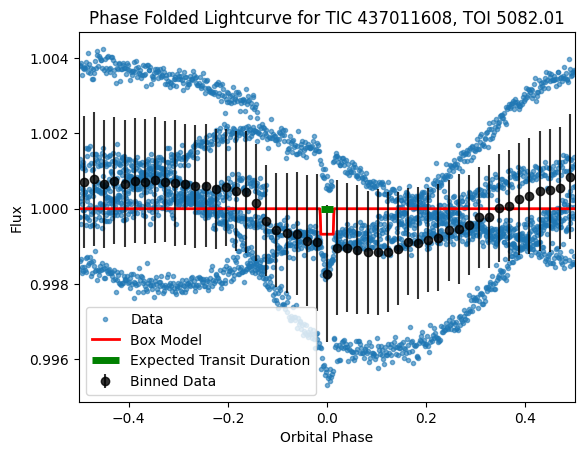

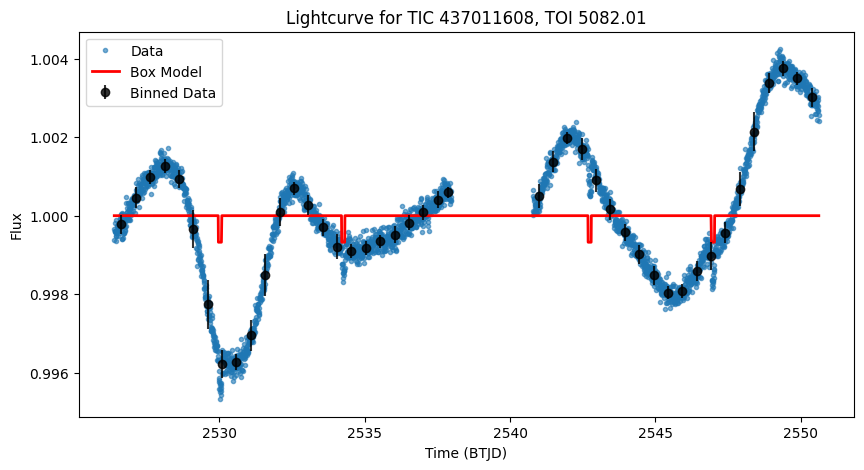

Plotting lightcurve for TIC 392681545, TOI 6054.01
       TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
9  6054.01  TIC 392681545      160.29            1.15              6111.67   

   Stellar Magnitude  True Radius (Earth Radii)  True Period (Days) Detection  \
9             7.4961                       2.53                 7.5     False   

   TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs   TLS FAP  \
9    6.200206                0.064998   0.999755   0.014069  0.017607   

     TLS SNR      toi         id tfopwg_disp         rastr         ra  \
9  12.494573  6054.01  392681545          CP  03h45m20.88s  56.337007   

         decstr        dec  st_pmra  st_pmraerr1  st_pmraerr2  st_pmralim  \
9  +60d21m03.3s  60.350917  -54.987        0.048       -0.048         0.0   

   st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim    pl_tranmid  \
9    -4.789          0.05         -0.05          0.0  2.459913e+06   

   pl_tranmiderr1  pl_tranmiderr2  pl_t

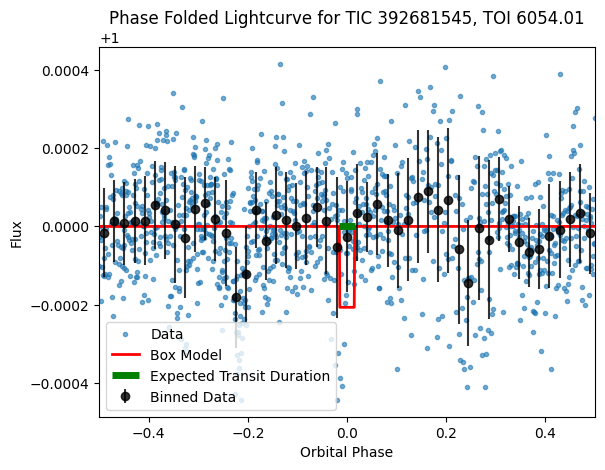

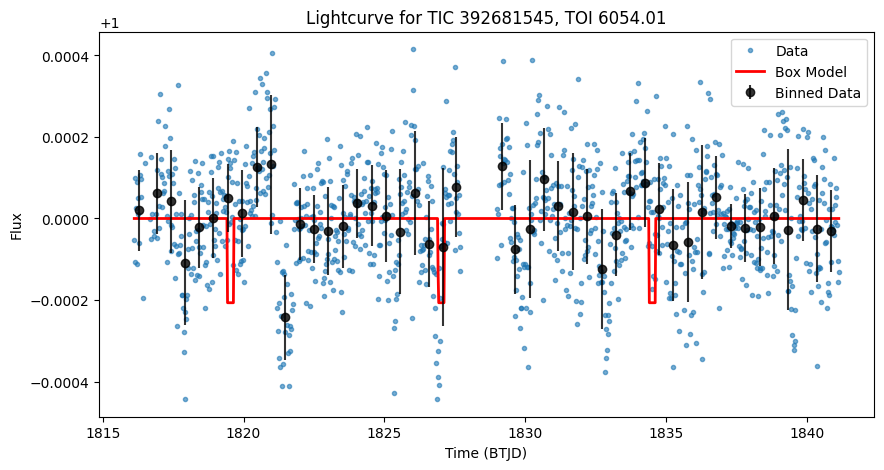

Plotting lightcurve for TIC 392681545, TOI 6054.02
        TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
10  6054.02  TIC 392681545      160.29            1.15              6111.67   

    Stellar Magnitude  True Radius (Earth Radii)  True Period (Days)  \
10             7.4961                        2.8                12.6   

   Detection  TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs  \
10     False    6.200206                0.064998   0.999755   0.014069   

     TLS FAP    TLS SNR      toi         id tfopwg_disp         rastr  \
10  0.017607  12.494573  6054.02  392681545          CP  03h45m20.88s   

           ra        decstr        dec  st_pmra  st_pmraerr1  st_pmraerr2  \
10  56.337007  +60d21m03.3s  60.350917  -54.987        0.048       -0.048   

    st_pmralim  st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim  \
10         0.0    -4.789          0.05         -0.05          0.0   

      pl_tranmid  pl_tranmiderr1  pl_tranmiderr2  pl_tr

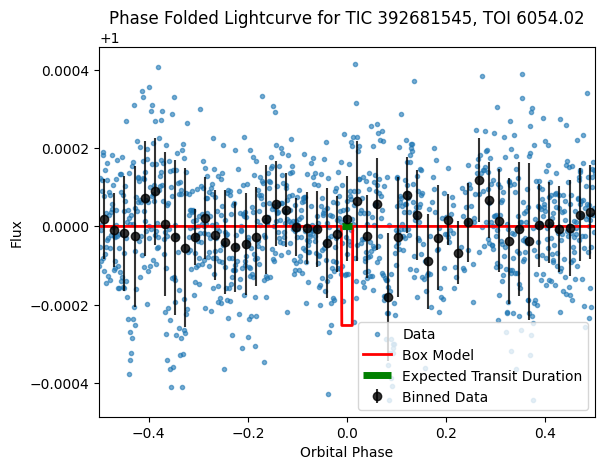

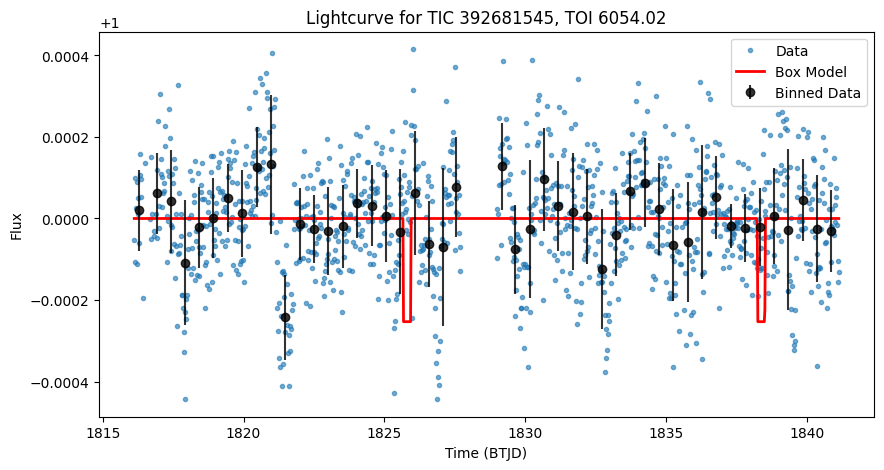

Plotting lightcurve for TIC 341405597, TOI 6699.01
        TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
11  6699.01  TIC 341405597      367.91            0.75               4716.0   

    Stellar Magnitude  True Radius (Earth Radii)  True Period (Days)  \
11            10.4012                       3.84                 5.3   

   Detection  TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs  \
11     False   14.218325                     inf   0.996059   0.056453   

    TLS FAP    TLS SNR      toi         id tfopwg_disp        rastr  \
11  0.00008  33.565598  6699.01  341405597          PC  21h08m16.7s   

            ra        decstr      dec  st_pmra  st_pmraerr1  st_pmraerr2  \
11  317.069584  -63d15m01.8s -63.2505  118.343        0.076       -0.076   

    st_pmralim  st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim  \
11         0.0   -45.719          0.09         -0.09          0.0   

      pl_tranmid  pl_tranmiderr1  pl_tranmiderr2  pl_tranmidl

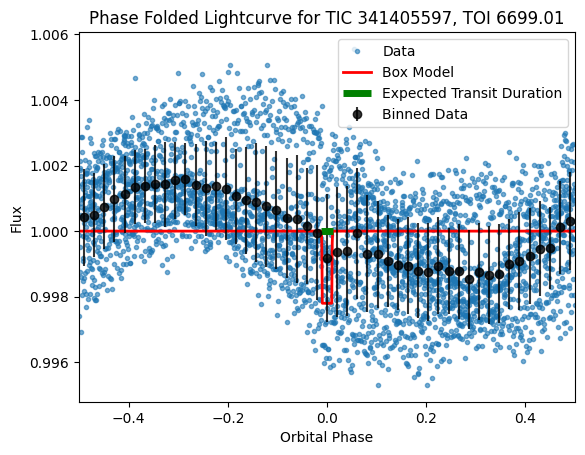

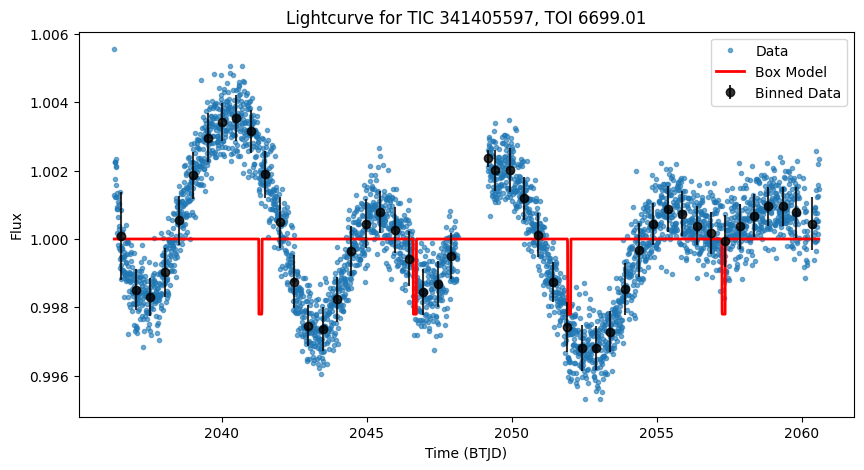

Plotting lightcurve for TIC 55450156, TOI 6826.01


        TOI           TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
12  6826.01  TIC 55450156      659.89            0.88               5203.0   

    Stellar Magnitude  True Radius (Earth Radii)  True Period (Days)  \
12            12.1851                       2.11                 6.4   

   Detection  TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs  \
12     False    9.441744                0.140336   0.998675   0.032738   

    TLS FAP   TLS SNR      toi        id tfopwg_disp         rastr         ra  \
12      NaN  7.774389  6826.01  55450156          PC  04h41m29.21s  70.371711   

          decstr        dec  st_pmra  st_pmraerr1  st_pmraerr2  st_pmralim  \
12  -60d24m27.2s -60.407556   26.668        0.043       -0.043         0.0   

    st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim    pl_tranmid  \
12     -9.86         0.051        -0.051          0.0  2.460197e+06   

    pl_tranmiderr1  pl_tranmiderr2  pl_tranmidlim  pl_orbper  pl_orbpererr1  \
12     

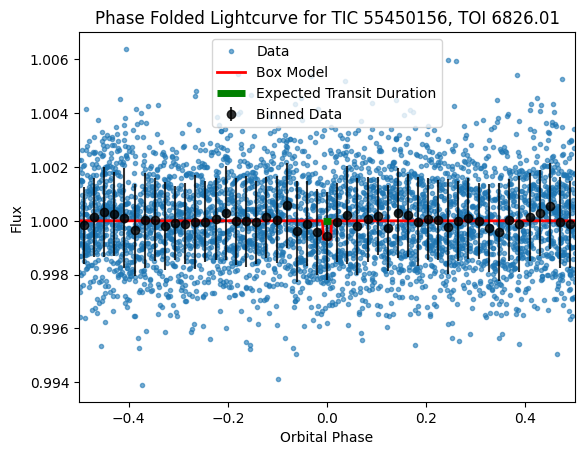

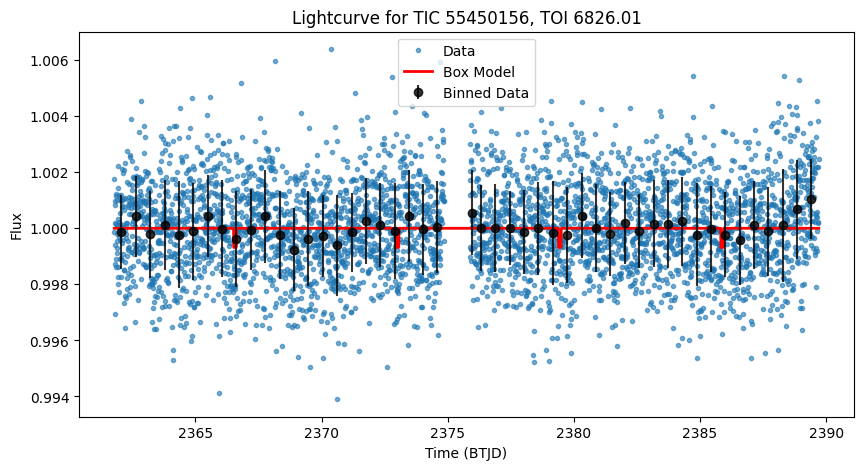

Plotting lightcurve for TIC 286712787, TOI 5159.01
Empty DataFrame
Columns: [TOI, TIC, CDPP (ppm), Stellar Radius, Stellar Temperature, Stellar Magnitude, True Radius (Earth Radii), True Period (Days), Detection, TLS Period, TLS Period Uncertainty, TLS Depth, TLS Rp/Rs, TLS FAP, TLS SNR, toi, id, tfopwg_disp, rastr, ra, decstr, dec, st_pmra, st_pmraerr1, st_pmraerr2, st_pmralim, st_pmdec, st_pmdecerr1, st_pmdecerr2, st_pmdeclim, pl_tranmid, pl_tranmiderr1, pl_tranmiderr2, pl_tranmidlim, pl_orbper, pl_orbpererr1, pl_orbpererr2, pl_orbperlim, pl_trandurh, pl_trandurherr1, pl_trandurherr2, pl_trandurhlim, pl_trandep, pl_trandeperr1, pl_trandeperr2, pl_trandeplim, pl_rade, pl_radeerr1, pl_radeerr2, pl_radelim, pl_insol, pl_insolerr1, pl_insolerr2, pl_insollim, pl_eqt, pl_eqterr1, pl_eqterr2, pl_eqtlim, st_tmag, st_tmagerr1, st_tmagerr2, st_tmaglim, st_dist, st_disterr1, st_disterr2, st_distlim, st_teff, st_tefferr1, st_tefferr2, st_tefflim, st_logg, st_loggerr1, st_loggerr2, st_logglim, st

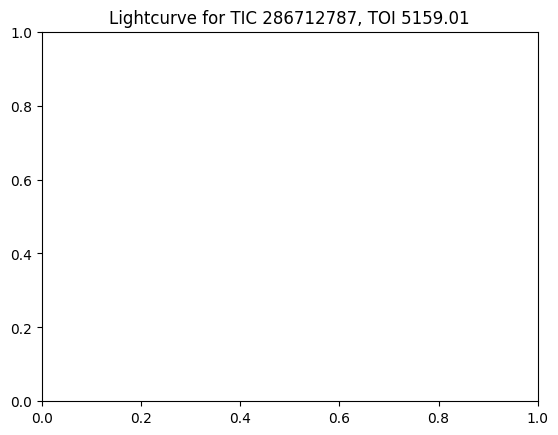

In [14]:
# Closer look at unexpected non-detections
full = df_full[df_full['Detection'] == 'False']
full = full.iloc[0:10]
#print(non_detections)
tic_ids = list(zip(full['TOI'], full['TIC']))
#print("List of (TOI, TIC) for non-detections above min:", tic_ids)
#tic_ids = list(zip(['733.01'], ['TIC 106402532']))

for toi, tic in tic_ids:
    print(f"Plotting lightcurve for {tic}, TOI {toi}")
    try:
        lc_collection = lk.search_lightcurve(tic, mission="TESS", author = 'TESS-SPOC', cadence='long').download_all(quality_bitmask="hard")
        #print(lc_collection)
        lc = lc_collection[-1].remove_nans().to_pandas().reset_index()
        df = lc[['time', 'flux']]
        # Get period and transit midtime from df_above_min for this TIC
        planet_row = df_above_min[df_above_min['TOI'] == toi]
        # Print all columns and their values for this row
        with pd.option_context('display.max_columns', None):
            print(planet_row)
        #print(planet_row)
        if not planet_row['pl_tranmid'].empty:
            period = planet_row['pl_orbper'].values[0]
            #print(period)
            t0 = planet_row['pl_tranmid'].values[0] - 2457000
            time = df['time'].values
            flux = df['flux'].values
            rp_earth = planet_row['True Radius (Earth Radii)'].values[0] 


            # Calculate expected transit depth (Rp/Rs)^2
            # Extract required values and check for NaNs
            stellar_mass = planet_row['mst'].values[0]
            r_star = planet_row['st_rad'].values[0]
            planet_radius = planet_row['True Radius (Earth Radii)'].values[0]
            transit_durh = planet_row['pl_trandurh'].values[0]  # in hours



            stellar_mass_kg = stellar_mass * (2 * (10 ** 30))
            r_star_m = r_star * 696340000
            period_in_seconds = period * 86400  # period in seconds
            a = (((period_in_seconds ** 2) * (6.67 * 10 ** -11) * stellar_mass_kg) / (4 * (3.1415 ** 2))) ** (1 / 3)  # meters
            r_star_earth = r_star_m / 6378000
            rp_rs = rp_earth / r_star_earth
            a_over_rstar = a / r_star_m



            expected_depth = rp_rs ** 2
            print(f"Expected transit depth: {expected_depth:.6f}, duration: {planet_row['pl_trandurh'].values[0]} hours")
            print(f"Period: {period}, Midtime: {t0}")

            # Phase fold
            phase_fit = ((time - t0 + 0.5 * period) % period) / period - 0.5
            sorted_fit = np.argsort(phase_fit)


            flux = flux / np.nanmean(flux)
            plt.plot(phase_fit[sorted_fit], flux[sorted_fit], '.', label='Data', alpha=0.6)

            print(f"Period: {period:.6f} days")
            print(f"Transit midtime (t0): {t0:.6f}")
            print(f"Planet/star radius ratio (Rp/Rs): {rp_rs:.6f}")
            print(f"Semi-major axis / stellar radius (a/Rs): {a_over_rstar:.6f}")

            if np.isnan(a_over_rstar):
                a_over_rstar = period_in_seconds / (transit_durh * 3600 * np.pi)
                print(a_over_rstar)
        


                        # Check for NaN in any required value
            nan_fields = []
            if np.isnan(a_over_rstar):
                nan_fields.append('a_over_rstar')
            if np.isnan(r_star_m):
                nan_fields.append('r_star_m (st_rad)')
            if np.isnan(planet_radius):
                nan_fields.append('planet_radius (True Radius (Earth Radii))')
            if nan_fields:
                print(f"Skipping batman fit for {tic} due to NaN in: {', '.join(nan_fields)}")
                continue

                        # 1. Set up batman transit parameters
            params = batman.TransitParams()
            params.t0 = t0  # phase 0.0 corresponds to transit center after folding
            params.per = period
            params.rp = rp_rs
            params.a = a_over_rstar 
            params.inc = 90.0  # edge-on
            params.ecc = 0.0
            params.w = 90.0
            params.u = [0.0, 0.0]  # no limb darkening for a box model
            params.limb_dark = "quadratic"

            # 2. Create batman model over the phase
            model_phase = np.linspace(-0.5, 0.5, 1000)
            model_time = model_phase * period + t0  # un-fold for batman input
            m = batman.TransitModel(params, model_time)
            model_flux = m.light_curve(params)

            # 3. Fold and sort the model flux same as data
            model_phase_folded = ((model_time - t0 + 0.5 * period) % period) / period - 0.5
            sorted_model = np.argsort(model_phase_folded)
            model_phase_folded = model_phase_folded[sorted_model]
            model_flux = model_flux[sorted_model]
            plt.plot(model_phase_folded, model_flux, '-', color='red', lw=2, label='Box Model')
            plt.legend()
            plt.xlabel("Orbital Phase")
            plt.ylabel("Flux")
            plt.xlim(-0.5, 0.5)

            # Bin the phase-folded data into 10 bins
            num_bins = 49
            bins = np.linspace(-0.5, 0.5, num_bins + 1)
            bin_indices = np.digitize(phase_fit, bins) - 1  # bin indices for each point

            binned_phase = []
            binned_flux = []
            binned_flux_std = []

            for i in range(num_bins):
                mask = bin_indices == i
                if np.any(mask):
                    binned_phase.append(np.mean(phase_fit[mask]))
                    binned_flux.append(np.mean(flux[mask]))
                    binned_flux_std.append(np.std(flux[mask]))
                else:
                    binned_phase.append((bins[i] + bins[i+1]) / 2)
                    binned_flux.append(np.nan)
                    binned_flux_std.append(np.nan)

            plt.errorbar(binned_phase, binned_flux, yerr=binned_flux_std, fmt='o', color='k', label='Binned Data', alpha=0.8)
            plt.legend()
            # Plot the expected transit duration as a horizontal line
            transit_phase = (transit_durh / 24) / period  # duration in phase units
            plt.hlines(1.0, -0.5 * transit_phase, 0.5 * transit_phase, color='green', lw=5, label='Expected Transit Duration')
            plt.legend()
            plt.title(f"Phase Folded Lightcurve for {tic}, TOI {toi}")
            #lt.ylim(.995, 1.005)
            #plt.xlim(-.1,.1)

            time_min = df['time'].min()
            time_max = df['time'].max()
            if not (time_min <= t0 <= time_max):
                print(f"⚠️  Warning: t0 ({t0}) is outside the observed TESS time range ({time_min} to {time_max})")
            else:
                print(f"✅  t0 ({t0}) is within the observed TESS time range ({time_min} to {time_max})")



            plt.figure(figsize=(10, 5))
            plt.plot(time, flux, '.', label='Data', alpha=0.6)

            # Generate batman model over the observed time range
            model_flux = batman.TransitModel(params, time).light_curve(params)
            plt.plot(time, model_flux, '-', color='red', lw=2, label='Box Model')
            num_bins = 49  # Number of bins for binning the raw light curve
            # Bin the raw light curve data
            bins = np.linspace(time.min(), time.max(), num_bins + 1)
            bin_indices = np.digitize(time, bins) - 1
            print('transit midpoint:', t0)
            binned_time = []
            binned_flux = []
            binned_flux_std = []

            for i in range(num_bins):
                mask = bin_indices == i
                if np.any(mask):
                    binned_time.append(np.mean(time[mask]))
                    binned_flux.append(np.mean(flux[mask]))
                    binned_flux_std.append(np.std(flux[mask]))
                else:
                    binned_time.append((bins[i] + bins[i+1]) / 2)
                    binned_flux.append(np.nan)
                    binned_flux_std.append(np.nan)

            plt.errorbar(binned_time, binned_flux, yerr=binned_flux_std, fmt='o', color='k', label='Binned Data', alpha=0.8)
            plt.xlabel("Time (BTJD)")
            plt.ylabel("Flux")
            plt.title(f"Raw Lightcurve for {tic}")
            plt.legend()
            #plt.ylim(.99,1.01)
            #plt.xlim(2089,2100)


        else:
            print('no midtime found for tic ', tic)
        plt.title(f"Lightcurve for {tic}, TOI {toi}")
        plt.show()
    except Exception as e:
        print(f"Error for {tic}: {e}")
        continue




/Users/danayaptangco/opt/anaconda3/envs/Mulders/lib/python3.9/site-packages/transitleastsquares/validate.py:57: UserWarning: Ignoring unknown parameter: max_period
  warnings.warn(text)


Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 37 durations
Searching 3081 data points, 2164 periods from 0.601 to 12.122 days
Using all 10 CPU threads


100%|██████████| 2164/2164 periods | 00:04<00:00


Searching for best T0 for period 10.53899 days
TLS Period: 10.538989060713666 True period: 4.2
TLS Transit duration (hours): 23.92514246098344 True transit duration (hours): 2.353


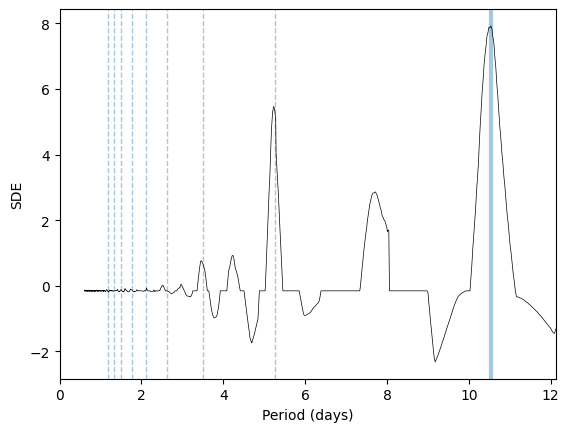

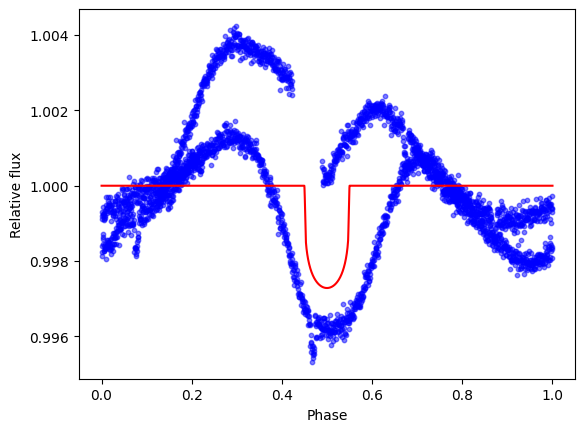

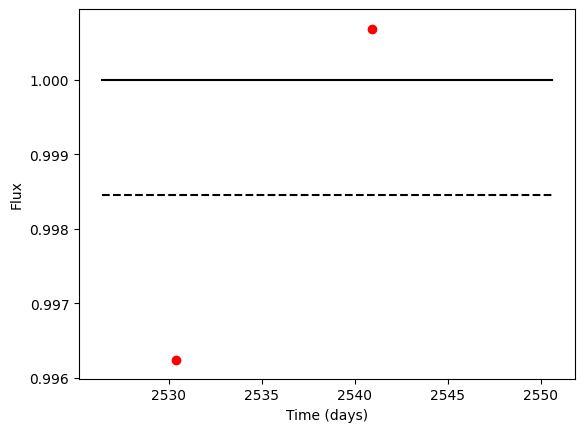

In [ ]:
from transitleastsquares import transitleastsquares
tls = transitleastsquares(time, flux)
results = tls.power(max_period = 14)

#Periodogram
plt.figure()
ax = plt.gca()
ax.axvline(results.period, alpha=0.4, lw=3)
plt.xlim(np.min(results.periods), np.max(results.periods))
for n in range(2, 10):
    ax.axvline(n*results.period, alpha=0.4, lw=1, linestyle="dashed")
    ax.axvline(results.period / n, alpha=0.4, lw=1, linestyle="dashed")
plt.ylabel(r'SDE')
plt.xlabel('Period (days)')
plt.plot(results.periods, results.power, color='black', lw=0.5)
plt.xlim(0, max(results.periods));
#plt.xlim(20.8, 21.0)
print("TLS Period:", results.period, "True period:", planet_row['True Period (Days)'].values[0])
print("TLS Transit duration (hours):", results.duration * 24, "True transit duration (hours):", planet_row['pl_trandurh'].values[0])

#TLS phase fold
plt.figure()
plt.scatter(results.folded_phase, results.folded_y, color='blue', s=10, alpha=0.5,)
plt.plot(results.model_folded_phase, results.model_folded_model, color='red')

plt.xlabel('Phase')
plt.ylabel('Relative flux');



plt.figure()
plt.errorbar(
    results.transit_times,
    results.transit_depths,
    yerr=results.transit_depths_uncertainties,
    fmt='o', color='red')
plt.plot(
    (time.min(), time.max()),
    (np.mean(results.transit_depths), np.mean(results.transit_depths)),
     color='black', linestyle='dashed')
plt.plot((time.min(), time.max()), (1, 1), color='black')
plt.xlabel('Time (days)')
plt.ylabel('Flux');


Plotting lightcurve for TIC 277833995, TOI 5524.01
        TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  \
51  5524.01  TIC 277833995      759.33            0.58               3650.0   

    Stellar Magnitude  True Radius (Earth Radii)  True Period (Days)  \
51             11.758                       2.33                 2.3   

   Detection  TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs  \
51     False    2.297631                   0.005   0.998809   0.031036   

     TLS FAP   TLS SNR      toi         id tfopwg_disp         rastr  \
51  0.087555  3.732505  5524.01  277833995          KP  10h25m37.32s   

            ra         decstr       dec  st_pmra  st_pmraerr1  st_pmraerr2  \
51  156.405499  +02d30m49.98s  2.513883   50.922         0.07        -0.07   

    st_pmralim  st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim  \
51         0.0  -109.198         0.067        -0.067          0.0   

      pl_tranmid  pl_tranmiderr1  pl_tranmiderr2  pl_tr

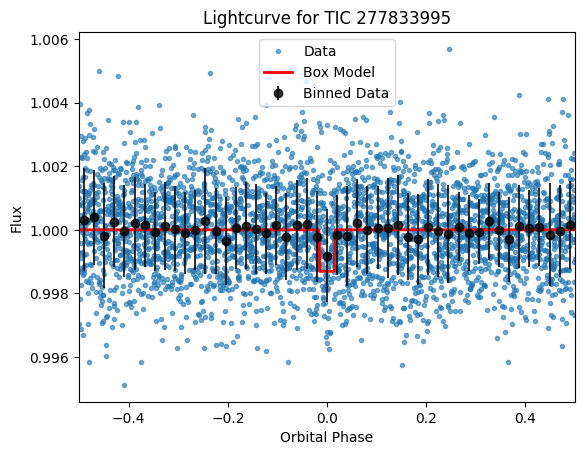

In [ ]:
# Closer look at unexpected non-detections

#non_detections = df_above_min[df_above_min['Detection'] == 'False']
#non_detections = non_detections.iloc[20:40]
#print(non_detections)
#tic_ids = list(zip(non_detections['TOI'], non_detections['TIC']))
#print("List of (TOI, TIC) for non-detections above min:", tic_ids)
tic_ids = list(zip(['5524.01'], ['TIC 277833995']))
#tic_ids = list(zip(['6699.01'], ['TIC 341405597']))

#277833995, TOI 5524.01
for toi, tic in tic_ids:
    print(f"Plotting lightcurve for {tic}, TOI {toi}")
    try:
        lc_collection = lk.search_lightcurve(tic, mission="TESS", cadence='long', author='TESS-SPOC').download_all(quality_bitmask="hard")
        #print(lc_collection)
        lc = lc_collection[-1].remove_nans().to_pandas().reset_index()
        df = lc[['time', 'flux']]
        # Get period and transit midtime from df_above_min for this TIC
        planet_row = df_above_min[df_above_min['TOI'] == toi]
        # Print all columns and their values for this row
        with pd.option_context('display.max_columns', None):
            print(planet_row)
        #print(planet_row)
        if not planet_row['pl_tranmid'].empty:
            period = planet_row['pl_orbper'].values[0]
            #print(period)
            t0 = planet_row['pl_tranmid'].values[0]
            t0 = planet_row['pl_tranmid'].values[0] - 2457000 
            time = df['time'].values
            flux = df['flux'].values
            rp_earth = planet_row['True Radius (Earth Radii)'].values[0] 


            # Calculate expected transit depth (Rp/Rs)^2
            stellar_mass_kg = (planet_row['mst'].values[0])*(2*(10**30))
            r_star_m = (planet_row['st_rad'].values[0])*(696340000)
            planet_radius = planet_row['True Radius (Earth Radii)'].values[0]
            star_radius = planet_row['Stellar Radius'].values[0]
            period = period
            period_in_seconds = period * 86400 # period in seconds
            a = (((period_in_seconds**2) * (6.67*10**-11) * stellar_mass_kg)/(4*(3.1415**2)))**(1/3) #meters
            r_star_earth = r_star_m / 6378000
            rp_rs = rp_earth / r_star_earth
            a_over_rstar = a / r_star_m


            expected_depth = rp_rs ** 2
            print(f"Expected transit depth: {expected_depth:.6f}, duration: {planet_row['pl_trandurh'].values[0]} hours")
            print(f"Period: {period}, Midtime: {t0}")

            # Phase fold
            phase_fit = ((time - t0 + 0.5 * period) % period) /period-.5
            sorted_fit = np.argsort(phase_fit)


            flux = flux / np.nanmean(flux)
            plt.plot(phase_fit[sorted_fit], flux[sorted_fit], '.', label='Data', alpha=0.6)


                        # 1. Set up batman transit parameters
            params = batman.TransitParams()
            params.t0 = t0  # phase 0.0 corresponds to transit center after folding
            params.per = period
            params.rp = rp_rs
            params.a = a_over_rstar 
            params.inc = 90.0  # edge-on
            params.ecc = 0.0
            params.w = 90.0
            params.u = [0.0, 0.0]  # no limb darkening for a box model
            params.limb_dark = "quadratic"

            # 2. Create batman model over the phase
            model_phase = np.linspace(-0.5, 0.5, 1000)
            model_time = model_phase * period + t0  # un-fold for batman input
            m = batman.TransitModel(params, model_time)
            model_flux = m.light_curve(params)

            # 3. Fold and sort the model flux same as data
            model_phase_folded = ((model_time - t0 + 0.5 * period) % period) /period- 0.5
            sorted_model = np.argsort(model_phase_folded)
            model_phase_folded = model_phase_folded[sorted_model]
            model_flux = model_flux[sorted_model]
            plt.plot(model_phase_folded, model_flux, '-', color='red', lw=2, label='Box Model')
            plt.legend()
            plt.xlabel("Orbital Phase")
            plt.ylabel("Flux")
            plt.xlim(-0.5, 0.5)

            # Bin the phase-folded data into 10 bins
            num_bins = 49
            bins = np.linspace(-0.5, 0.5, num_bins + 1)
            bin_indices = np.digitize(phase_fit, bins) - 1  # bin indices for each point

            binned_phase = []
            binned_flux = []
            binned_flux_std = []

            for i in range(num_bins):
                mask = bin_indices == i
                if np.any(mask):
                    binned_phase.append(np.mean(phase_fit[mask]))
                    binned_flux.append(np.mean(flux[mask]))
                    binned_flux_std.append(np.std(flux[mask]))
                else:
                    binned_phase.append((bins[i] + bins[i+1]) / 2)
                    binned_flux.append(np.nan)
                    binned_flux_std.append(np.nan)

            plt.errorbar(binned_phase, binned_flux, yerr=binned_flux_std, fmt='o', color='k', label='Binned Data', alpha=0.8)
            plt.legend()
            #plt.ylim(.995, 1.005)

        else:
            print('no midtime found for tic ', tic)
        plt.title(f"Lightcurve for {tic}")
        plt.show()
    except Exception as e:
        print(f"Error for {tic}: {e}")
        continue


#!Try binning as well
#!find why we're getting long period
#! overplot expected transit
#! plot and phase fold the ones I did detect
#! can even do transit with two points out of transit and one within to see dip

#! try running tess multi-sector on first 20 but only up to period 14
#! next step is to do multi-sector onn ones that I still don't see by eye
# 2.458518e+06 -2457000

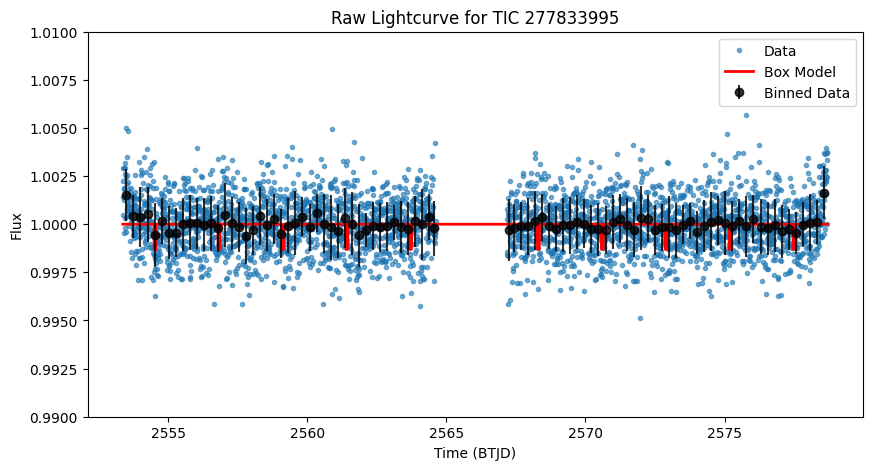

In [ ]:
# Plot the raw light curve and the batman model (not phase folded)

plt.figure(figsize=(10, 5))
plt.plot(time, flux, '.', label='Data', alpha=0.6)

# Generate batman model over the observed time range
model_flux_time = batman.TransitModel(params, time).light_curve(params)
plt.plot(time, model_flux_time, '-', color='red', lw=2, label='Box Model')

# Bin the raw light curve data
num_bins = 100
bins = np.linspace(time.min(), time.max(), num_bins + 1)
bin_indices = np.digitize(time, bins) - 1

binned_time = []
binned_flux = []
binned_flux_std = []

for i in range(num_bins):
    mask = bin_indices == i
    if np.any(mask):
        binned_time.append(np.mean(time[mask]))
        binned_flux.append(np.mean(flux[mask]))
        binned_flux_std.append(np.std(flux[mask]))
    else:
        binned_time.append((bins[i] + bins[i+1]) / 2)
        binned_flux.append(np.nan)
        binned_flux_std.append(np.nan)

plt.errorbar(binned_time, binned_flux, yerr=binned_flux_std, fmt='o', color='k', label='Binned Data', alpha=0.8)
plt.xlabel("Time (BTJD)")
plt.ylabel("Flux")
plt.title(f"Raw Lightcurve for {tic}")
plt.legend()
plt.ylim(.99,1.01)
plt.show()

#where do I turn this into BJD?